# Accumulated Local Effects (ALE) Analysis for EMC Dataset

This notebook analyzes the accumulated local effects on the same feature set as the SHAP analysis.
We use Leave-One-Subject-Out (LOSO) cross-validation with proper ALE computation:

1. For each fold, fit the full pipeline on training subjects
2. Compute quantile bins on training data of that fold
3. Compute ALE curve on training data using the fitted model
4. Aggregate across folds with proper interpolation and weighting

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import tqdm
from scipy import interpolate
from scipy.stats import t
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

DATA_FOLDER = '/space/gzanardini/emc_whole/split'
# Best parameters from SHAP analysis
best_parameters = {
    'spectral': ('Cz',          10 ,    'std'),
    'cwt':      ('BipolarDB',   2,      'median'),
    'dwt':      ('Laplacian',   10,     'median'),
    'mst':      ('BipolarDB',   60,     'median'),
    'sst':      ('CAR',         10,     'median'),
    'cc':       ('CAR',         1,      'std'),
    'plv':      ('Laplacian',   60,      'kurt'),
    'gcc':      ('CAR',         60,      'median'),
    'gplv':     ('Laplacian',   2,      'std'),
    'utm':      ('Laplacian',   20,     'std')
}

In [4]:
def load_data():
    """Load and prepare the dataset."""
    description = pd.read_csv(f'{DATA_FOLDER}/description.csv')
    labels = description['epilepsy'].to_numpy()
    subjects = description['subject'].to_numpy()
    unique_subjects = np.unique(description['subject'])
    
    subject_labels = []
    for subj in unique_subjects:
        lbl = labels[subjects == subj][0]
        subject_labels.append([subj, lbl])
    subject_labels = np.array(subject_labels)
    
    return description, labels, subjects, unique_subjects, subject_labels

def load_feature_data(feature_name):
    """Load and preprocess feature data using the best parameters for the given feature."""
    montage, segment_length, combiner = best_parameters[feature_name]
    data = np.load(f'{DATA_FOLDER}/{feature_name}_{montage}_{segment_length}s_{combiner}.npy')
    data = handle_complex_numbers(data)
    
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
    return data, montage, segment_length, combiner

def handle_complex_numbers(features):
    """Handle complex numbers and infinite values in features."""
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

In [5]:
# Load data
description, labels, subjects, unique_subjects, subject_labels = load_data()

# Channel names for PLV feature naming
chs = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
       'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

def plv_index_to_name(idx, ch=None):
    bands = ['raw','delta','theta','alpha','beta','gamma']
    if ch is None:
        ch = ['FP1_Lap','F3_Lap','C3_Lap','P3_Lap','F7_Lap','T3_Lap','T5_Lap','O1_Lap',
              'FZ_Lap','CZ_Lap','PZ_Lap','FP2_Lap','F4_Lap','C4_Lap','P4_Lap',
              'F8_Lap','T4_Lap','T6_Lap','O2_Lap']

    P = len(ch)*(len(ch)-1)//2  # 171
    band_id, pair_id = divmod(idx, P)

    # Recover the (j,k) pair that lives at position pair_id
    j = next(j for j in range(1, len(ch)) if j*(j+1)//2 > pair_id)
    k = pair_id - j*(j-1)//2

    return f"PLV_{bands[band_id]}_{ch[j]}-{ch[k]}"

feature_names = [plv_index_to_name(i, ch=chs) for i in range(1026)]

In [6]:
def compute_ale_1d(model, X_train, feature_idx, n_bins=20):
    """
    Compute 1D Accumulated Local Effects for a single feature.
    
    Parameters:
    -----------
    model : fitted model
        The trained model to explain
    X_train : np.ndarray
        Training data used to compute quantile bins
    feature_idx : int
        Index of the feature to compute ALE for
    n_bins : int
        Number of quantile bins to use
    
    Returns:
    --------
    ale_values : np.ndarray
        ALE values at bin centers
    bin_centers : np.ndarray
        Feature values at bin centers
    bin_counts : np.ndarray
        Number of samples in each bin
    """
    feature_values = X_train[:, feature_idx]
    
    # Remove NaN values
    valid_mask = ~np.isnan(feature_values)
    if not np.any(valid_mask):
        return np.array([]), np.array([]), np.array([])
    
    feature_values = feature_values[valid_mask]
    X_valid = X_train[valid_mask]
    
    # Create quantile bins on training data
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.quantile(feature_values, quantiles)
    
    # Ensure unique bin edges
    bin_edges = np.unique(bin_edges)
    if len(bin_edges) < 3:  # Need at least 2 bins
        return np.array([]), np.array([]), np.array([])
    
    # Compute ALE
    ale_values = []
    bin_centers = []
    bin_counts = []
    
    for i in range(len(bin_edges) - 1):
        # Find samples in this bin
        in_bin = (feature_values >= bin_edges[i]) & (feature_values < bin_edges[i + 1])
        if i == len(bin_edges) - 2:  # Last bin includes right edge
            in_bin = (feature_values >= bin_edges[i]) & (feature_values <= bin_edges[i + 1])
        
        if np.sum(in_bin) == 0:
            continue
            
        X_bin = X_valid[in_bin]
        
        # Create copies with feature values at bin edges
        X_lower = X_bin.copy()
        X_upper = X_bin.copy()
        X_lower[:, feature_idx] = bin_edges[i]
        X_upper[:, feature_idx] = bin_edges[i + 1]
        
        # Get predictions
        pred_lower = model.predict_proba(X_lower)[:, 1]
        pred_upper = model.predict_proba(X_upper)[:, 1]
        
        # Local effect for this bin
        local_effect = np.mean(pred_upper - pred_lower)
        ale_values.append(local_effect)
        
        # Bin center and count
        bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
        bin_counts.append(np.sum(in_bin))
    
    if len(ale_values) == 0:
        return np.array([]), np.array([]), np.array([])
    
    ale_values = np.array(ale_values)
    bin_centers = np.array(bin_centers)
    bin_counts = np.array(bin_counts)
    
    # Accumulate local effects
    ale_cumsum = np.cumsum(ale_values)
    
    # Center ALE (subtract weighted mean)
    weighted_mean = np.average(ale_cumsum, weights=bin_counts)
    ale_cumsum -= weighted_mean
    
    return ale_cumsum, bin_centers, bin_counts

In [7]:
def interpolate_ale_to_common_grid(ale_values, bin_centers, common_grid):
    """
    Interpolate ALE values to a common grid.
    
    Parameters:
    -----------
    ale_values : np.ndarray
        ALE values from one fold
    bin_centers : np.ndarray
        Bin centers from one fold
    common_grid : np.ndarray
        Common grid to interpolate to
    
    Returns:
    --------
    interpolated_ale : np.ndarray
        ALE values interpolated to common grid
    """
    if len(ale_values) == 0 or len(bin_centers) == 0:
        return np.full(len(common_grid), np.nan)
    
    # Only interpolate within the range of the original data
    min_val, max_val = bin_centers.min(), bin_centers.max()
    
    # Find valid grid points
    valid_mask = (common_grid >= min_val) & (common_grid <= max_val)
    
    interpolated_ale = np.full(len(common_grid), np.nan)
    
    if np.any(valid_mask):
        # Linear interpolation
        f = interpolate.interp1d(bin_centers, ale_values, kind='linear', 
                               bounds_error=False, fill_value=np.nan)
        interpolated_ale[valid_mask] = f(common_grid[valid_mask])
    
    return interpolated_ale

In [8]:
def aggregate_ale_across_folds(fold_results, n_grid_points=100):
    """
    Aggregate ALE results across folds.
    
    Parameters:
    -----------
    fold_results : list
        List of (ale_values, bin_centers, bin_counts, n_train) for each fold
    n_grid_points : int
        Number of points in common grid
    
    Returns:
    --------
    common_grid : np.ndarray
        Common grid points
    mean_ale : np.ndarray
        Mean ALE across folds
    std_ale : np.ndarray
        Standard deviation of ALE across folds
    ci_lower : np.ndarray
        Lower 95% confidence interval
    ci_upper : np.ndarray
        Upper 95% confidence interval
    """
    # Extract valid results
    valid_results = [(ale, centers, counts, n_train) for ale, centers, counts, n_train in fold_results 
                    if len(ale) > 0 and len(centers) > 0]
    
    if len(valid_results) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([]), np.array([])
    
    # Determine common grid range
    all_centers = np.concatenate([centers for _, centers, _, _ in valid_results])
    min_val, max_val = np.percentile(all_centers, [5, 95])  # Use 5-95% range to avoid outliers
    
    common_grid = np.linspace(min_val, max_val, n_grid_points)
    
    # Interpolate each fold to common grid
    interpolated_ales = []
    fold_weights = []
    
    for ale_values, bin_centers, bin_counts, n_train in valid_results:
        # Center the ALE values (in case not done already)
        ale_centered = ale_values - np.average(ale_values, weights=bin_counts)
        
        # Interpolate to common grid
        interpolated = interpolate_ale_to_common_grid(ale_centered, bin_centers, common_grid)
        interpolated_ales.append(interpolated)
        fold_weights.append(n_train)
    
    interpolated_ales = np.array(interpolated_ales)
    fold_weights = np.array(fold_weights)
    
    # Compute weighted statistics
    valid_mask = ~np.isnan(interpolated_ales)
    
    mean_ale = np.full(n_grid_points, np.nan)
    std_ale = np.full(n_grid_points, np.nan)
    ci_lower = np.full(n_grid_points, np.nan)
    ci_upper = np.full(n_grid_points, np.nan)
    
    for i in range(n_grid_points):
        valid_i = valid_mask[:, i]
        if np.sum(valid_i) > 1:  # Need at least 2 folds for statistics
            values = interpolated_ales[valid_i, i]
            weights = fold_weights[valid_i]
            
            # Weighted mean
            mean_ale[i] = np.average(values, weights=weights)
            
            # Unbiased standard deviation (not weighted for simplicity)
            std_ale[i] = np.std(values, ddof=1)
            
            # 95% confidence interval using t-distribution
            n_folds = len(values)
            t_val = t.ppf(0.975, n_folds - 1)
            margin = t_val * std_ale[i] / np.sqrt(n_folds)
            ci_lower[i] = mean_ale[i] - margin
            ci_upper[i] = mean_ale[i] + margin
    
    return common_grid, mean_ale, std_ale, ci_lower, ci_upper

In [10]:
def plot_ale_results(common_grid, mean_ale, std_ale, ci_lower, ci_upper, 
                    feature_name, feature_idx, montage, segment_length, combiner,
                    individual_folds=None):
    """
    Plot ALE results with confidence intervals.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot individual fold curves (faint)
    if individual_folds is not None:
        for fold_ale in individual_folds:
            plt.plot(common_grid, fold_ale, 'lightgray', alpha=0.4, linewidth=0.5)
    
    # Plot confidence interval
    valid_mask = ~np.isnan(mean_ale)
    if np.any(valid_mask):
        plt.fill_between(common_grid[valid_mask], ci_lower[valid_mask], ci_upper[valid_mask], 
                        alpha=0.3, color='blue', label='95% CI')
        
        # Plot mean ALE
        plt.plot(common_grid[valid_mask], mean_ale[valid_mask], 'b-', linewidth=2, label='Mean ALE')
        
        # Plot zero line
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.xlabel(f'Feature {feature_idx} Value')
    plt.ylabel('ALE (Change in Prediction)')
    plt.title(f'ALE Plot for {feature_name} Feature {feature_idx}\n'
              f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return plt.gcf()

In [8]:
# Main ALE analysis for PLV features
feature_name = 'plv'
data, montage, segment_length, combiner = load_feature_data(feature_name)
print(f"Data shape: {data.shape}")
data = handle_complex_numbers(data)

# Select a subset of important features for ALE analysis (computational efficiency)
# You can modify this to analyze all features or specific ones
n_features_to_analyze = 10  # Analyze top 10 most variable features
feature_variances = np.nanvar(data, axis=0)
top_feature_indices = np.argsort(feature_variances)[-n_features_to_analyze:]

print(f"Analyzing {n_features_to_analyze} features with highest variance:")
for i, feat_idx in enumerate(top_feature_indices):
    if feat_idx < len(feature_names):
        print(f"  {i+1}. Feature {feat_idx}: {feature_names[feat_idx]}")
    else:
        print(f"  {i+1}. Feature {feat_idx}: Feature_{feat_idx}")

Data shape: (141, 1026)
Analyzing 10 features with highest variance:
  1. Feature 387: PLV_theta_PZ-FP1
  2. Feature 179: PLV_delta_F7-C3
  3. Feature 775: PLV_beta_P4-FP1
  4. Feature 1005: PLV_gamma_T6-P4
  5. Feature 898: PLV_gamma_CZ-O1
  6. Feature 349: PLV_theta_F7-F3
  7. Feature 939: PLV_gamma_C4-T5
  8. Feature 813: PLV_beta_T4-CZ
  9. Feature 942: PLV_gamma_C4-CZ
  10. Feature 973: PLV_gamma_F8-C4


In [9]:
# Compute ALE for each feature across all LOSO folds
ale_results = {}

for feat_idx in tqdm.tqdm(top_feature_indices, desc='Computing ALE for features'):
    fold_results = []
    
    # LOSO cross-validation
    for subj in tqdm.tqdm(unique_subjects, desc=f'LOSO folds for feature {feat_idx}', leave=False):
        test_indices = np.where(subjects == subj)[0]
        train_indices = np.where(subjects != subj)[0]
        
        X_train, X_test = data[train_indices], data[test_indices]
        y_train, y_test = labels[train_indices], labels[test_indices]
        
        # Handle missing values in training data
        feature_train = X_train[:, feat_idx]
        if np.all(np.isnan(feature_train)) or len(np.unique(feature_train[~np.isnan(feature_train)])) < 3:
            continue
        
        # Train model
        ratio = (len(y_train) - sum(y_train)) / max(sum(y_train), 1)
        
        model = XGBClassifier(
            scale_pos_weight=ratio,
            n_jobs=4,
            
            device='cpu',
            n_estimators=100,
            max_depth=6,
            subsample=0.9,
            gamma=0.1,
            learning_rate=0.01,
            random_state=42
        )
        
        try:
            model.fit(X_train, y_train)
            
            # Compute ALE for this fold
            ale_values, bin_centers, bin_counts = compute_ale_1d(model, X_train, feat_idx, n_bins=20)
            
            if len(ale_values) > 0:
                fold_results.append((ale_values, bin_centers, bin_counts, len(X_train)))
                
        except Exception as e:
            print(f"Error in fold {subj} for feature {feat_idx}: {e}")
            continue
    
    if len(fold_results) > 2:  # Need at least 3 folds for meaningful aggregation
        # Aggregate across folds
        common_grid, mean_ale, std_ale, ci_lower, ci_upper = aggregate_ale_across_folds(fold_results)
        
        ale_results[feat_idx] = {
            'common_grid': common_grid,
            'mean_ale': mean_ale,
            'std_ale': std_ale,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_folds': len(fold_results),
            'fold_results': fold_results
        }
        
        print(f"Feature {feat_idx}: {len(fold_results)} successful folds")
    else:
        print(f"Feature {feat_idx}: Insufficient folds ({len(fold_results)}), skipping")

print(f"\nCompleted ALE analysis for {len(ale_results)} features")

Computing ALE for features:  10%|█         | 1/10 [03:35<32:15, 215.08s/it]

Feature 387: 141 successful folds


Computing ALE for features:  20%|██        | 2/10 [07:19<29:23, 220.46s/it]

Feature 179: 141 successful folds


Computing ALE for features:  30%|███       | 3/10 [11:08<26:10, 224.33s/it]

...

Feature 813: 141 successful folds


Computing ALE for features:  90%|█████████ | 9/10 [34:29<03:54, 234.03s/it]

Feature 942: 141 successful folds


Computing ALE for features: 100%|██████████| 10/10 [38:23<00:00, 230.31s/it]

Feature 973: 141 successful folds

Completed ALE analysis for 10 features


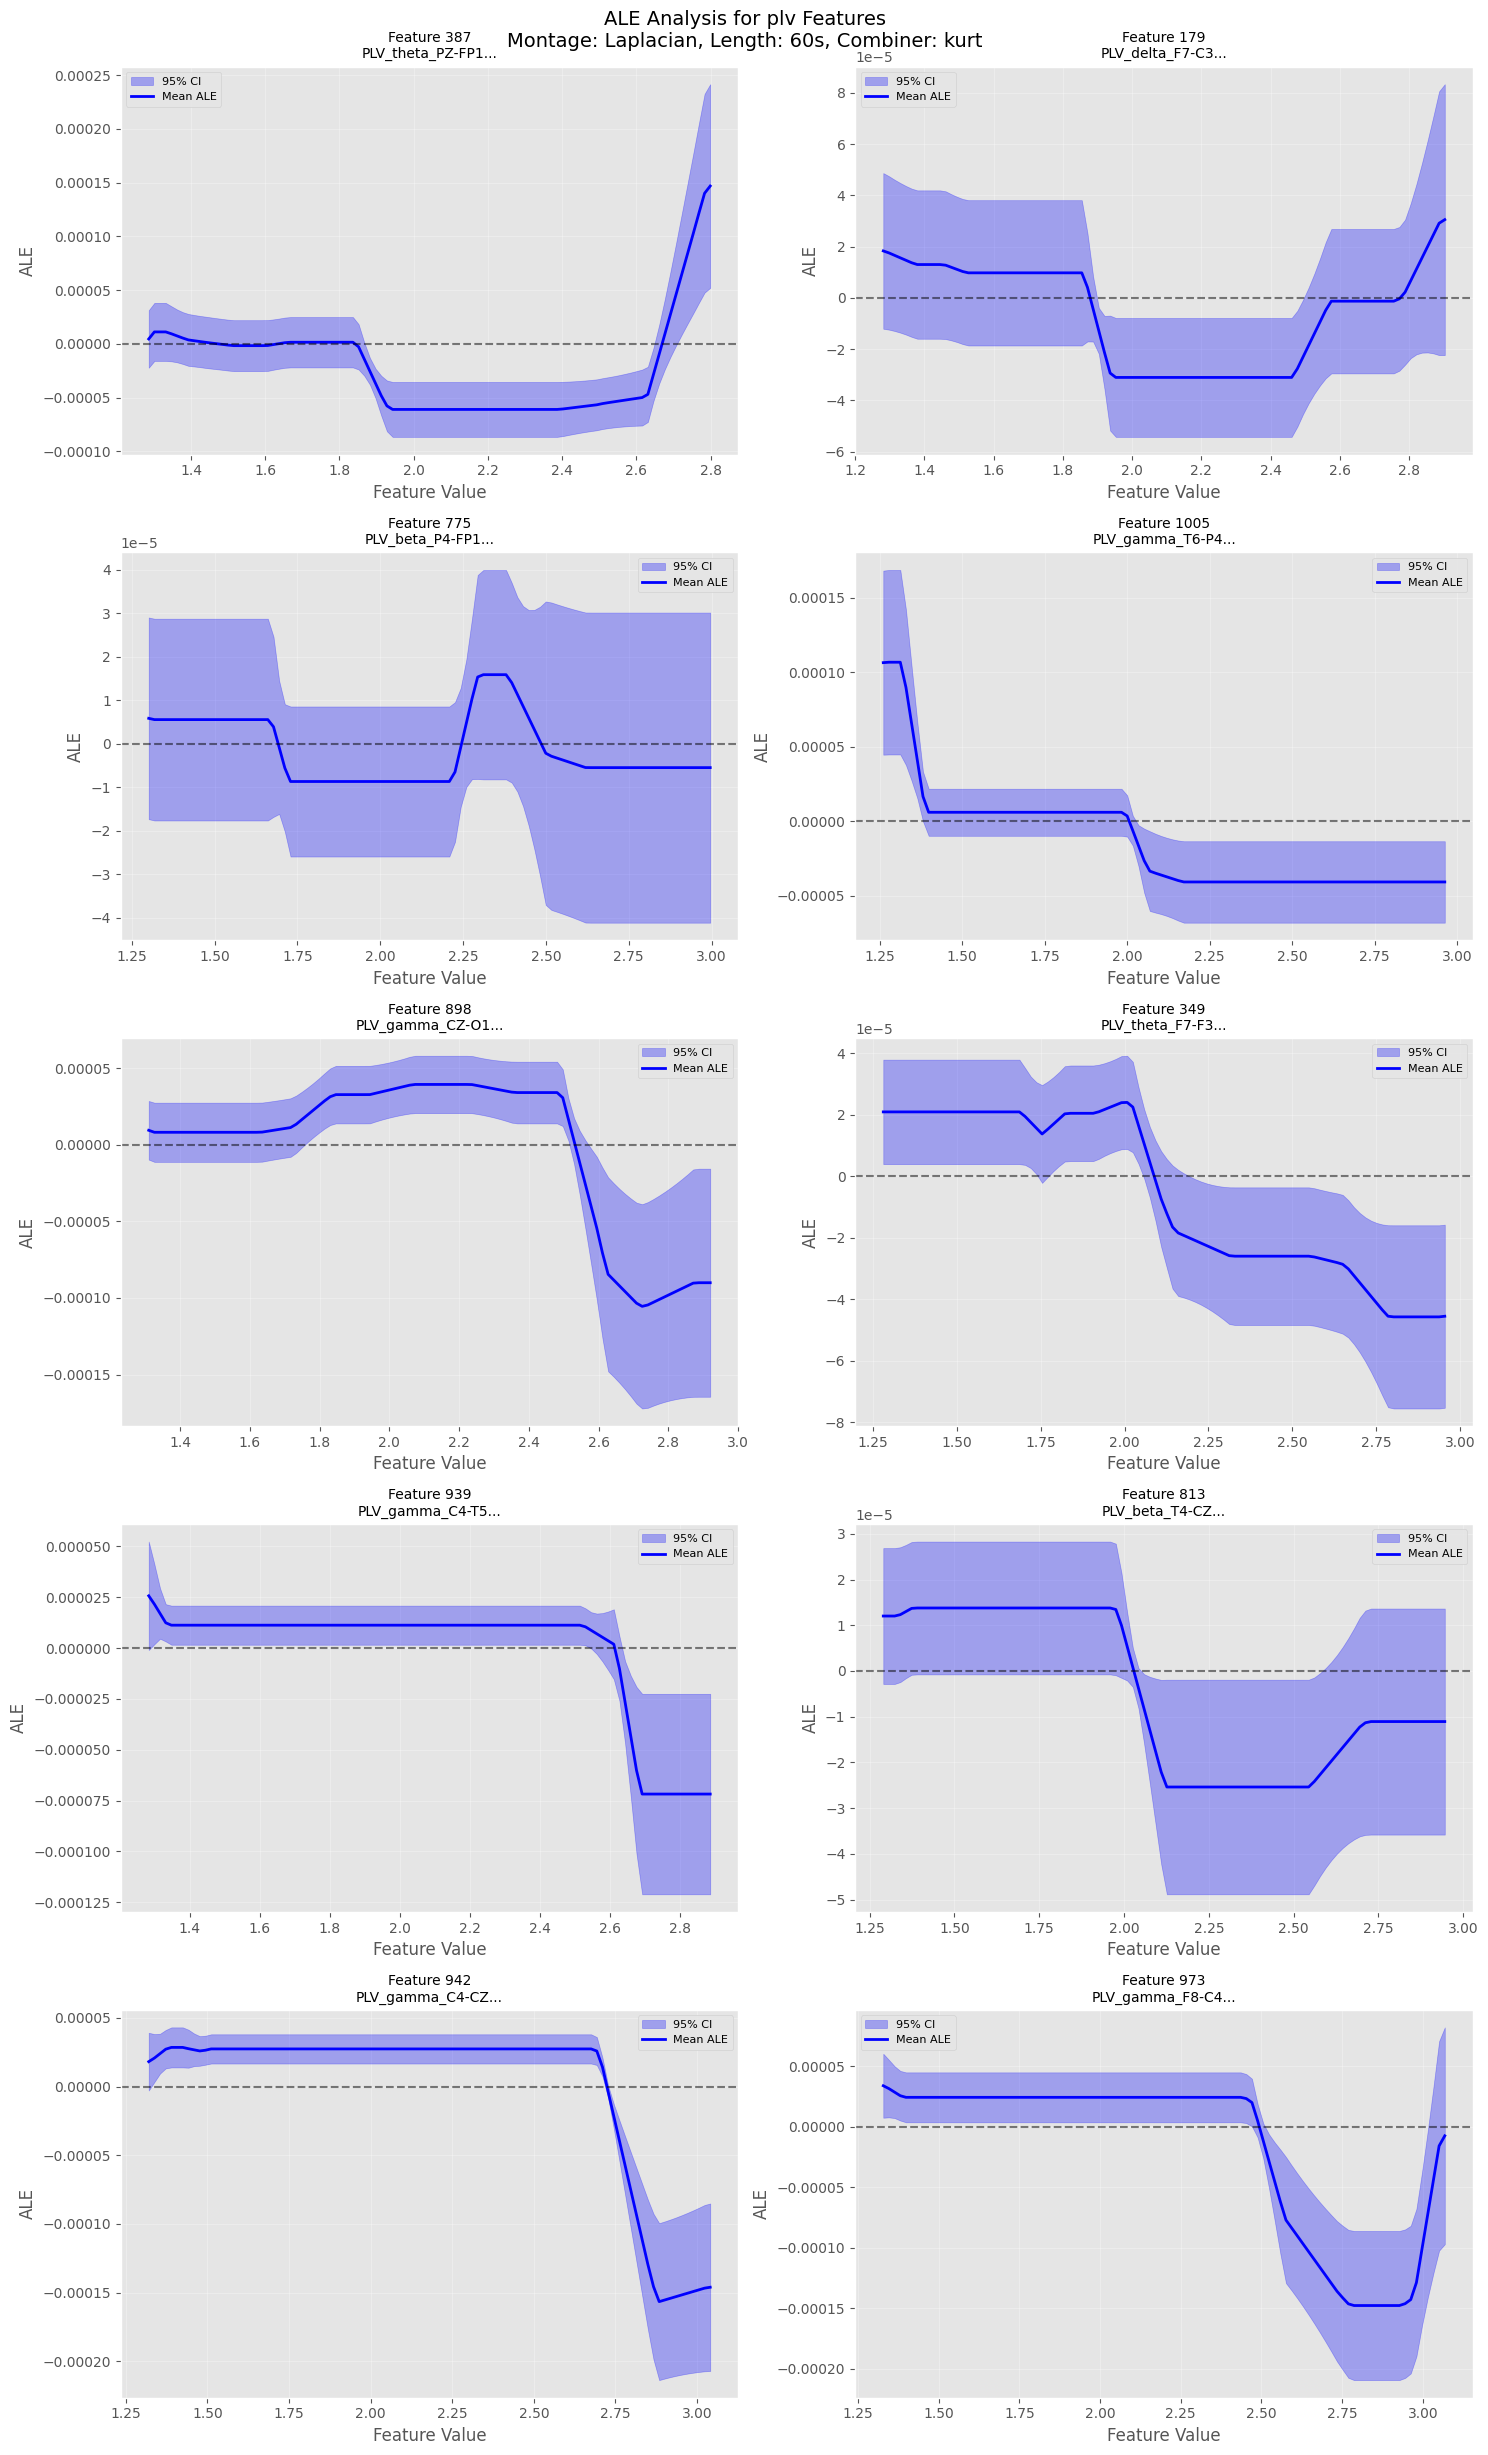

In [10]:
# Plot ALE results for each analyzed feature
n_cols = 2
n_rows = (len(ale_results) + n_cols - 1) // n_cols

if len(ale_results) > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, (feat_idx, results) in enumerate(ale_results.items()):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        common_grid = results['common_grid']
        mean_ale = results['mean_ale']
        ci_lower = results['ci_lower']
        ci_upper = results['ci_upper']
        
        # Plot confidence interval
        valid_mask = ~np.isnan(mean_ale)
        if np.any(valid_mask):
            ax.fill_between(common_grid[valid_mask], ci_lower[valid_mask], ci_upper[valid_mask], 
                           alpha=0.3, color='blue', label='95% CI')
            ax.plot(common_grid[valid_mask], mean_ale[valid_mask], 'b-', linewidth=2, label='Mean ALE')
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Feature name
        if feat_idx < len(feature_names):
            title = f'Feature {feat_idx}\n{feature_names[feat_idx]}...'
        else:
            title = f'Feature {feat_idx}'
        
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Feature Value')
        ax.set_ylabel('ALE')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    # Hide empty subplots
    for i in range(len(ale_results), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].set_visible(False)
    
    plt.suptitle(f'ALE Analysis for {feature_name} Features\n'
                 f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}', 
                 fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("No successful ALE results to plot")


Top 3 features by ALE variance:
  1. Feature 973: PLV_gamma_F8-C4 (variance: 0.000000)
  2. Feature 942: PLV_gamma_C4-CZ (variance: 0.000000)
  3. Feature 898: PLV_gamma_CZ-O1 (variance: 0.000000)


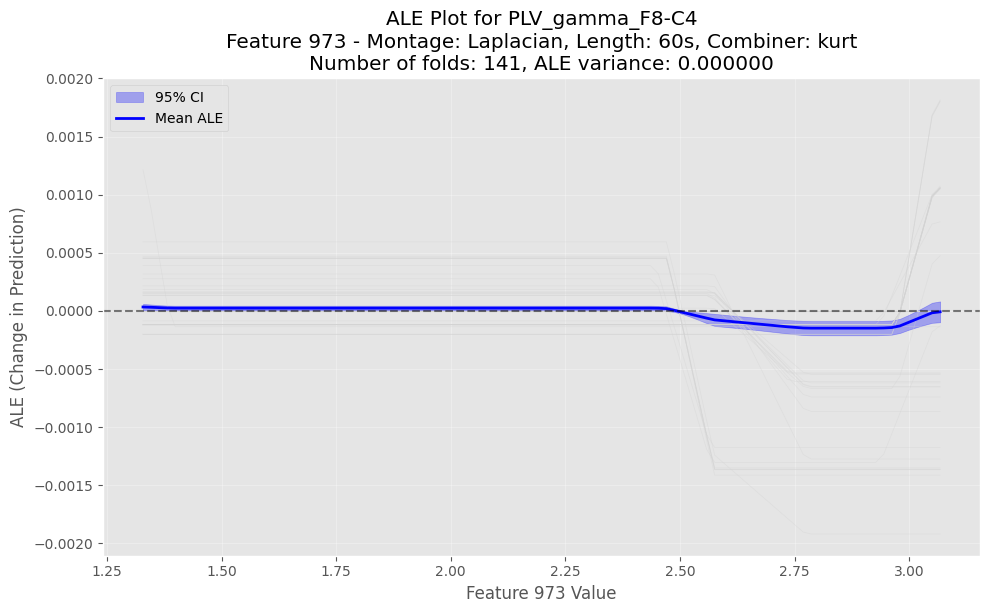

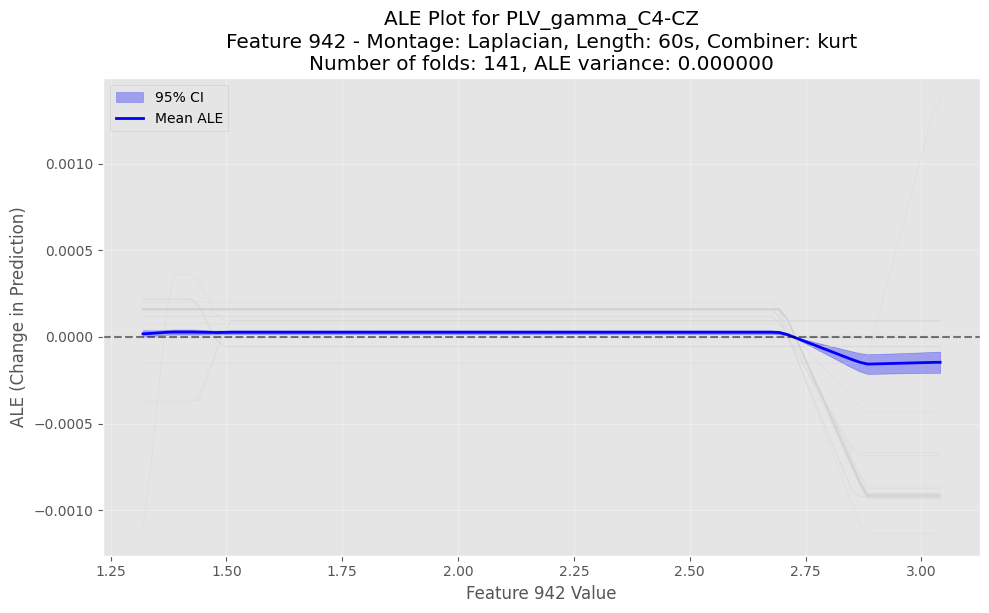

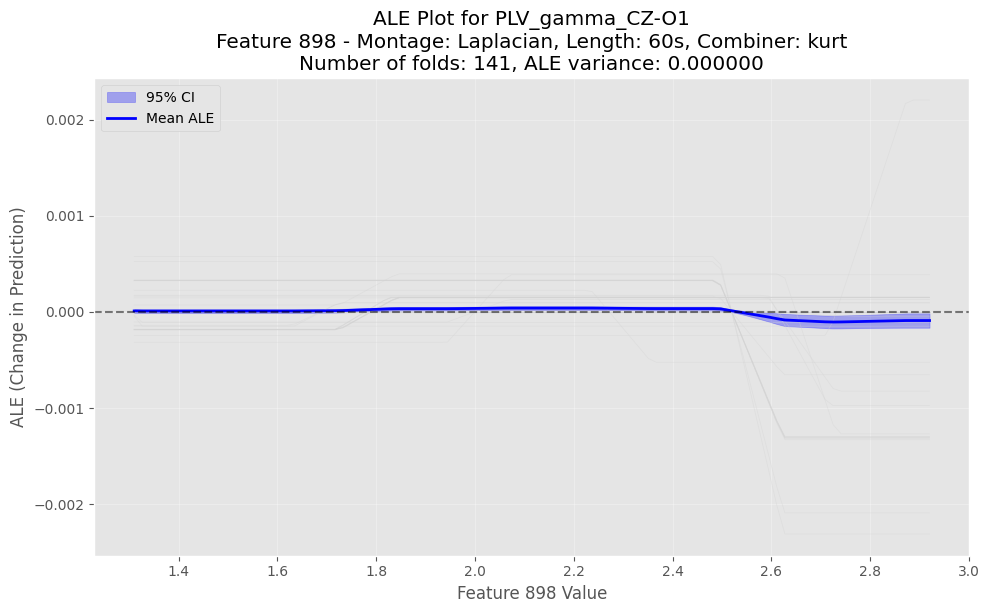

In [11]:
# Create individual detailed plots for the most interesting features
# (features with highest ALE variance)
if len(ale_results) > 0:
    # Compute ALE variance for each feature to identify most interesting ones
    ale_variances = {}
    for feat_idx, results in ale_results.items():
        mean_ale = results['mean_ale']
        valid_mask = ~np.isnan(mean_ale)
        if np.any(valid_mask):
            ale_variances[feat_idx] = np.var(mean_ale[valid_mask])
        else:
            ale_variances[feat_idx] = 0
    
    # Sort by variance and plot top 3
    sorted_features = sorted(ale_variances.items(), key=lambda x: x[1], reverse=True)
    top_3_features = sorted_features[:3]
    
    print("\nTop 3 features by ALE variance:")
    for i, (feat_idx, variance) in enumerate(top_3_features):
        if feat_idx < len(feature_names):
            print(f"  {i+1}. Feature {feat_idx}: {feature_names[feat_idx]} (variance: {variance:.6f})")
        else:
            print(f"  {i+1}. Feature {feat_idx}: Feature_{feat_idx} (variance: {variance:.6f})")
    
    # Create detailed plots
    for feat_idx, variance in top_3_features:
        results = ale_results[feat_idx]
        
        # Collect individual fold ALE curves for plotting
        individual_folds = []
        for ale_values, bin_centers, bin_counts, n_train in results['fold_results']:
            ale_centered = ale_values - np.average(ale_values, weights=bin_counts)
            interpolated = interpolate_ale_to_common_grid(ale_centered, bin_centers, results['common_grid'])
            individual_folds.append(interpolated)
        
        # Create detailed plot
        fig = plot_ale_results(
            results['common_grid'], results['mean_ale'], results['std_ale'], 
            results['ci_lower'], results['ci_upper'],
            feature_name, feat_idx, montage, segment_length, combiner,
            individual_folds=individual_folds
        )
        
        # Add feature name to title if available
        if feat_idx < len(feature_names):
            plt.title(f'ALE Plot for {feature_names[feat_idx]}\n'
                     f'Feature {feat_idx} - Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}\n'
                     f'Number of folds: {results["n_folds"]}, ALE variance: {variance:.6f}')
        
        plt.show()
        
        # Save the plot
        plt.savefig(f'ale_{feature_name}_feature_{feat_idx}_emc.pdf', dpi=300, bbox_inches='tight')
        plt.close()

else:
    print("No ALE results available for detailed plotting")

In [29]:
# Summary statistics
print("\n=== ALE Analysis Summary ===")
print(f"Feature type: {feature_name}")
print(f"Montage: {montage}, Segment length: {segment_length}s, Combiner: {combiner}")
print(f"Total features in dataset: {data.shape[1]}")
print(f"Features analyzed: {len(top_feature_indices)}")
print(f"Successful ALE computations: {len(ale_results)}")
print(f"Total subjects (LOSO folds): {len(unique_subjects)}")

if len(ale_results) > 0:
    avg_folds = np.mean([results['n_folds'] for results in ale_results.values()])
    print(f"Average successful folds per feature: {avg_folds:.1f}")
    
    # Report features with strongest ALE effects
    print("\nFeatures with strongest ALE effects (by max absolute ALE):")
    max_ale_effects = {}
    for feat_idx, results in ale_results.items():
        mean_ale = results['mean_ale']
        valid_mask = ~np.isnan(mean_ale)
        if np.any(valid_mask):
            max_ale_effects[feat_idx] = np.max(np.abs(mean_ale[valid_mask]))
        else:
            max_ale_effects[feat_idx] = 0
    
    sorted_effects = sorted(max_ale_effects.items(), key=lambda x: x[1], reverse=True)
    for i, (feat_idx, max_effect) in enumerate(sorted_effects[:5]):
        if feat_idx < len(feature_names):
            print(f"  {i+1}. Feature {feat_idx}: {feature_names[feat_idx][:60]}... (max |ALE|: {max_effect:.4f})")
        else:
            print(f"  {i+1}. Feature {feat_idx}: Feature_{feat_idx} (max |ALE|: {max_effect:.4f})")

print("\nALE analysis completed!")


=== ALE Analysis Summary ===
Feature type: plv
Montage: Laplacian, Segment length: 60s, Combiner: kurt
Total features in dataset: 1026
Features analyzed: 10
Successful ALE computations: 10
Total subjects (LOSO folds): 141
Average successful folds per feature: 141.0

Features with strongest ALE effects (by max absolute ALE):
  1. Feature 942: PLV_gamma_C4-CZ... (max |ALE|: 0.0002)
  2. Feature 973: PLV_gamma_F8-C4... (max |ALE|: 0.0001)
  3. Feature 387: PLV_theta_PZ-FP1... (max |ALE|: 0.0001)
  4. Feature 1005: PLV_gamma_T6-P4... (max |ALE|: 0.0001)
  5. Feature 898: PLV_gamma_CZ-O1... (max |ALE|: 0.0001)

ALE analysis completed!


# repeating the above experiments with the top 10 lowest p values sing brunner munzel test (bonferroni corrected) and then for features 327, 711, 232, 224 587.



In [ ]:
from scipy.stats import brunnermunzel
from statsmodels.stats.multitest import multipletests

In [14]:
def compute_brunner_munzel_features(data, labels, alpha=0.05):
    """
    Compute Brunner-Munzel test for each feature and return top features with lowest p-values.
    
    Parameters:
    -----------
    data : np.ndarray
        Feature matrix (n_samples, n_features)
    labels : np.ndarray
        Binary labels (0/1)
    alpha : float
        Significance level for Bonferroni correction
    
    Returns:
    --------
    top_features : np.ndarray
        Indices of top 10 features with lowest corrected p-values
    p_values : np.ndarray
        Original p-values for all features
    corrected_p_values : np.ndarray
        Bonferroni corrected p-values
    """
    n_features = data.shape[1]
    p_values = np.full(n_features, 1.0)
    statistics = np.full(n_features, 0.0)
    
    # Separate groups
    group_0 = labels == 0  # Non-epileptic
    group_1 = labels == 1  # Epileptic
    
    print(f"Computing Brunner-Munzel test for {n_features} features...")
    print(f"Group 0 (non-epileptic): {np.sum(group_0)} samples")
    print(f"Group 1 (epileptic): {np.sum(group_1)} samples")
    
    for i in tqdm.tqdm(range(n_features), desc="Computing Brunner-Munzel tests"):
        feature_data = data[:, i]
        
        # Remove NaN values
        valid_mask = ~np.isnan(feature_data)
        if np.sum(valid_mask) < 10:  # Need at least 10 valid samples
            continue
            
        feature_valid = feature_data[valid_mask]
        labels_valid = labels[valid_mask]
        
        group_0_valid = labels_valid == 0
        group_1_valid = labels_valid == 1
        
        if np.sum(group_0_valid) < 3 or np.sum(group_1_valid) < 3:  # Need at least 3 samples per group
            continue
            
        data_0 = feature_valid[group_0_valid]
        data_1 = feature_valid[group_1_valid]
        
        try:
            # Brunner-Munzel test
            statistic, p_value = brunnermunzel(data_0, data_1, alternative='two-sided')
            p_values[i] = p_value
            statistics[i] = statistic
        except Exception as e:
            print(f"Error in feature {i}: {e}")
            continue
    
    # Bonferroni correction
    valid_tests = p_values < 1.0  # Features that were actually tested
    corrected_p_values = np.full(n_features, 1.0)
    
    if np.any(valid_tests):
        valid_p_values = p_values[valid_tests]
        _, corrected_valid, _, _ = multipletests(valid_p_values, alpha=alpha, method='bonferroni')
        corrected_p_values[valid_tests] = corrected_valid
    
    # Get top 10 features with lowest corrected p-values
    valid_features = np.where(valid_tests)[0]
    if len(valid_features) > 0:
        sorted_indices = np.argsort(corrected_p_values[valid_features])
        top_10_valid = valid_features[sorted_indices[:10]]
    else:
        top_10_valid = np.array([])
    
    return top_10_valid, p_values, corrected_p_values

In [15]:
# Compute Brunner-Munzel test for all features
print("=== BRUNNER-MUNZEL FEATURE SELECTION ===")
bm_top_features, bm_p_values, bm_corrected_p_values = compute_brunner_munzel_features(data, labels)

print(f"\nTop 10 features with lowest Bonferroni-corrected p-values:")
for i, feat_idx in enumerate(bm_top_features):
    p_val = bm_p_values[feat_idx]
    corrected_p_val = bm_corrected_p_values[feat_idx]
    if feat_idx < len(feature_names):
        feat_name = feature_names[feat_idx]
    else:
        feat_name = f"Feature_{feat_idx}"
    
    print(f"  {i+1}. Feature {feat_idx}: {feat_name}")
    print(f"      Original p-value: {p_val:.2e}, Corrected p-value: {corrected_p_val:.2e}")

# Also analyze specific features mentioned: 327, 711, 232, 224, 587
specific_features = [327, 711, 232, 224, 587]
print(f"\nSpecific features to analyze: {specific_features}")

# Combine both sets of features for analysis
features_to_analyze = np.unique(np.concatenate([bm_top_features, specific_features]))
print(f"Total features to analyze: {len(features_to_analyze)}")

for feat_idx in specific_features:
    if feat_idx < data.shape[1]:
        p_val = bm_p_values[feat_idx] if feat_idx < len(bm_p_values) else 1.0
        corrected_p_val = bm_corrected_p_values[feat_idx] if feat_idx < len(bm_corrected_p_values) else 1.0
        if feat_idx < len(feature_names):
            feat_name = feature_names[feat_idx]
        else:
            feat_name = f"Feature_{feat_idx}"
        print(f"  Feature {feat_idx}: {feat_name}")
        print(f"    Original p-value: {p_val:.2e}, Corrected p-value: {corrected_p_val:.2e}")
    else:
        print(f"  Feature {feat_idx}: Index out of range (data has {data.shape[1]} features)")

=== BRUNNER-MUNZEL FEATURE SELECTION ===
Computing Brunner-Munzel test for 1026 features...
Group 0 (non-epileptic): 101 samples
Group 1 (epileptic): 40 samples


Computing Brunner-Munzel tests: 100%|██████████| 1026/1026 [00:01<00:00, 787.00it/s]


Top 10 features with lowest Bonferroni-corrected p-values:
  1. Feature 232: PLV_delta_FP2-T5
      Original p-value: 7.41e-05, Corrected p-value: 7.61e-02
  2. Feature 327: PLV_delta_O2-P3
      Original p-value: 2.66e-04, Corrected p-value: 2.73e-01
  3. Feature 97: PLV_raw_P4-T5
      Original p-value: 7.89e-04, Corrected p-value: 8.10e-01
  4. Feature 0: PLV_raw_F3-FP1
      Original p-value: 4.89e-01, Corrected p-value: 1.00e+00
  5. Feature 676: PLV_alpha_O2-PZ
      Original p-value: 5.99e-01, Corrected p-value: 1.00e+00
  6. Feature 677: PLV_alpha_O2-FP2
      Original p-value: 9.93e-01, Corrected p-value: 1.00e+00
  7. Feature 678: PLV_alpha_O2-F4
      Original p-value: 2.08e-02, Corrected p-value: 1.00e+00
  8. Feature 679: PLV_alpha_O2-C4
      Original p-value: 2.15e-01, Corrected p-value: 1.00e+00
  9. Feature 680: PLV_alpha_O2-P4
      Original p-value: 7.96e-02, Corrected p-value: 1.00e+00
  10. Feature 681: PLV_alpha_O2-F8
      Original p-value: 8.58e-02, Corrected p

In [16]:
# Compute ALE for Brunner-Munzel selected features and specific features
print("\n=== ALE ANALYSIS FOR BRUNNER-MUNZEL SELECTED FEATURES ===")
bm_ale_results = {}

for feat_idx in tqdm.tqdm(features_to_analyze, desc='Computing ALE for BM-selected features'):
    if feat_idx >= data.shape[1]:
        print(f"Skipping feature {feat_idx}: Index out of range")
        continue
        
    fold_results = []
    
    # LOSO cross-validation
    for subj in tqdm.tqdm(unique_subjects, desc=f'LOSO folds for feature {feat_idx}', leave=False):
        test_indices = np.where(subjects == subj)[0]
        train_indices = np.where(subjects != subj)[0]
        
        X_train, X_test = data[train_indices], data[test_indices]
        y_train, y_test = labels[train_indices], labels[test_indices]
        
        # Handle missing values in training data
        feature_train = X_train[:, feat_idx]
        if np.all(np.isnan(feature_train)) or len(np.unique(feature_train[~np.isnan(feature_train)])) < 3:
            continue
        
        # Train model
        ratio = (len(y_train) - sum(y_train)) / max(sum(y_train), 1)
        
        model = XGBClassifier(
            scale_pos_weight=ratio,
            n_jobs=4,
            device='cpu',
            n_estimators=100,
            max_depth=6,
            subsample=0.9,
            gamma=0.1,
            learning_rate=0.01,
            random_state=42
        )
        
        try:
            model.fit(X_train, y_train)
            
            # Compute ALE for this fold
            ale_values, bin_centers, bin_counts = compute_ale_1d(model, X_train, feat_idx, n_bins=20)
            
            if len(ale_values) > 0:
                fold_results.append((ale_values, bin_centers, bin_counts, len(X_train)))
                
        except Exception as e:
            print(f"Error in fold {subj} for feature {feat_idx}: {e}")
            continue
    
    if len(fold_results) > 2:  # Need at least 3 folds for meaningful aggregation
        # Aggregate across folds
        common_grid, mean_ale, std_ale, ci_lower, ci_upper = aggregate_ale_across_folds(fold_results)
        
        bm_ale_results[feat_idx] = {
            'common_grid': common_grid,
            'mean_ale': mean_ale,
            'std_ale': std_ale,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_folds': len(fold_results),
            'fold_results': fold_results,
            'p_value': bm_p_values[feat_idx] if feat_idx < len(bm_p_values) else 1.0,
            'corrected_p_value': bm_corrected_p_values[feat_idx] if feat_idx < len(bm_corrected_p_values) else 1.0
        }
        
        print(f"Feature {feat_idx}: {len(fold_results)} successful folds")
    else:
        print(f"Feature {feat_idx}: Insufficient folds ({len(fold_results)}), skipping")

print(f"\nCompleted ALE analysis for {len(bm_ale_results)} BM-selected features")


=== ALE ANALYSIS FOR BRUNNER-MUNZEL SELECTED FEATURES ===


Computing ALE for BM-selected features:   8%|▊         | 1/13 [03:57<47:31, 237.59s/it]

Feature 0: 141 successful folds


Computing ALE for BM-selected features:  15%|█▌        | 2/13 [07:59<44:02, 240.23s/it]

Feature 97: 141 successful folds


...

Feature 680: 141 successful folds


Computing ALE for BM-selected features:  92%|█████████▏| 12/13 [48:01<04:01, 241.49s/it]

Feature 681: 141 successful folds


Computing ALE for BM-selected features: 100%|██████████| 13/13 [52:03<00:00, 240.23s/it]

Feature 711: 141 successful folds

Completed ALE analysis for 13 BM-selected features



=== PLOTTING ALE RESULTS FOR BRUNNER-MUNZEL SELECTED FEATURES ===


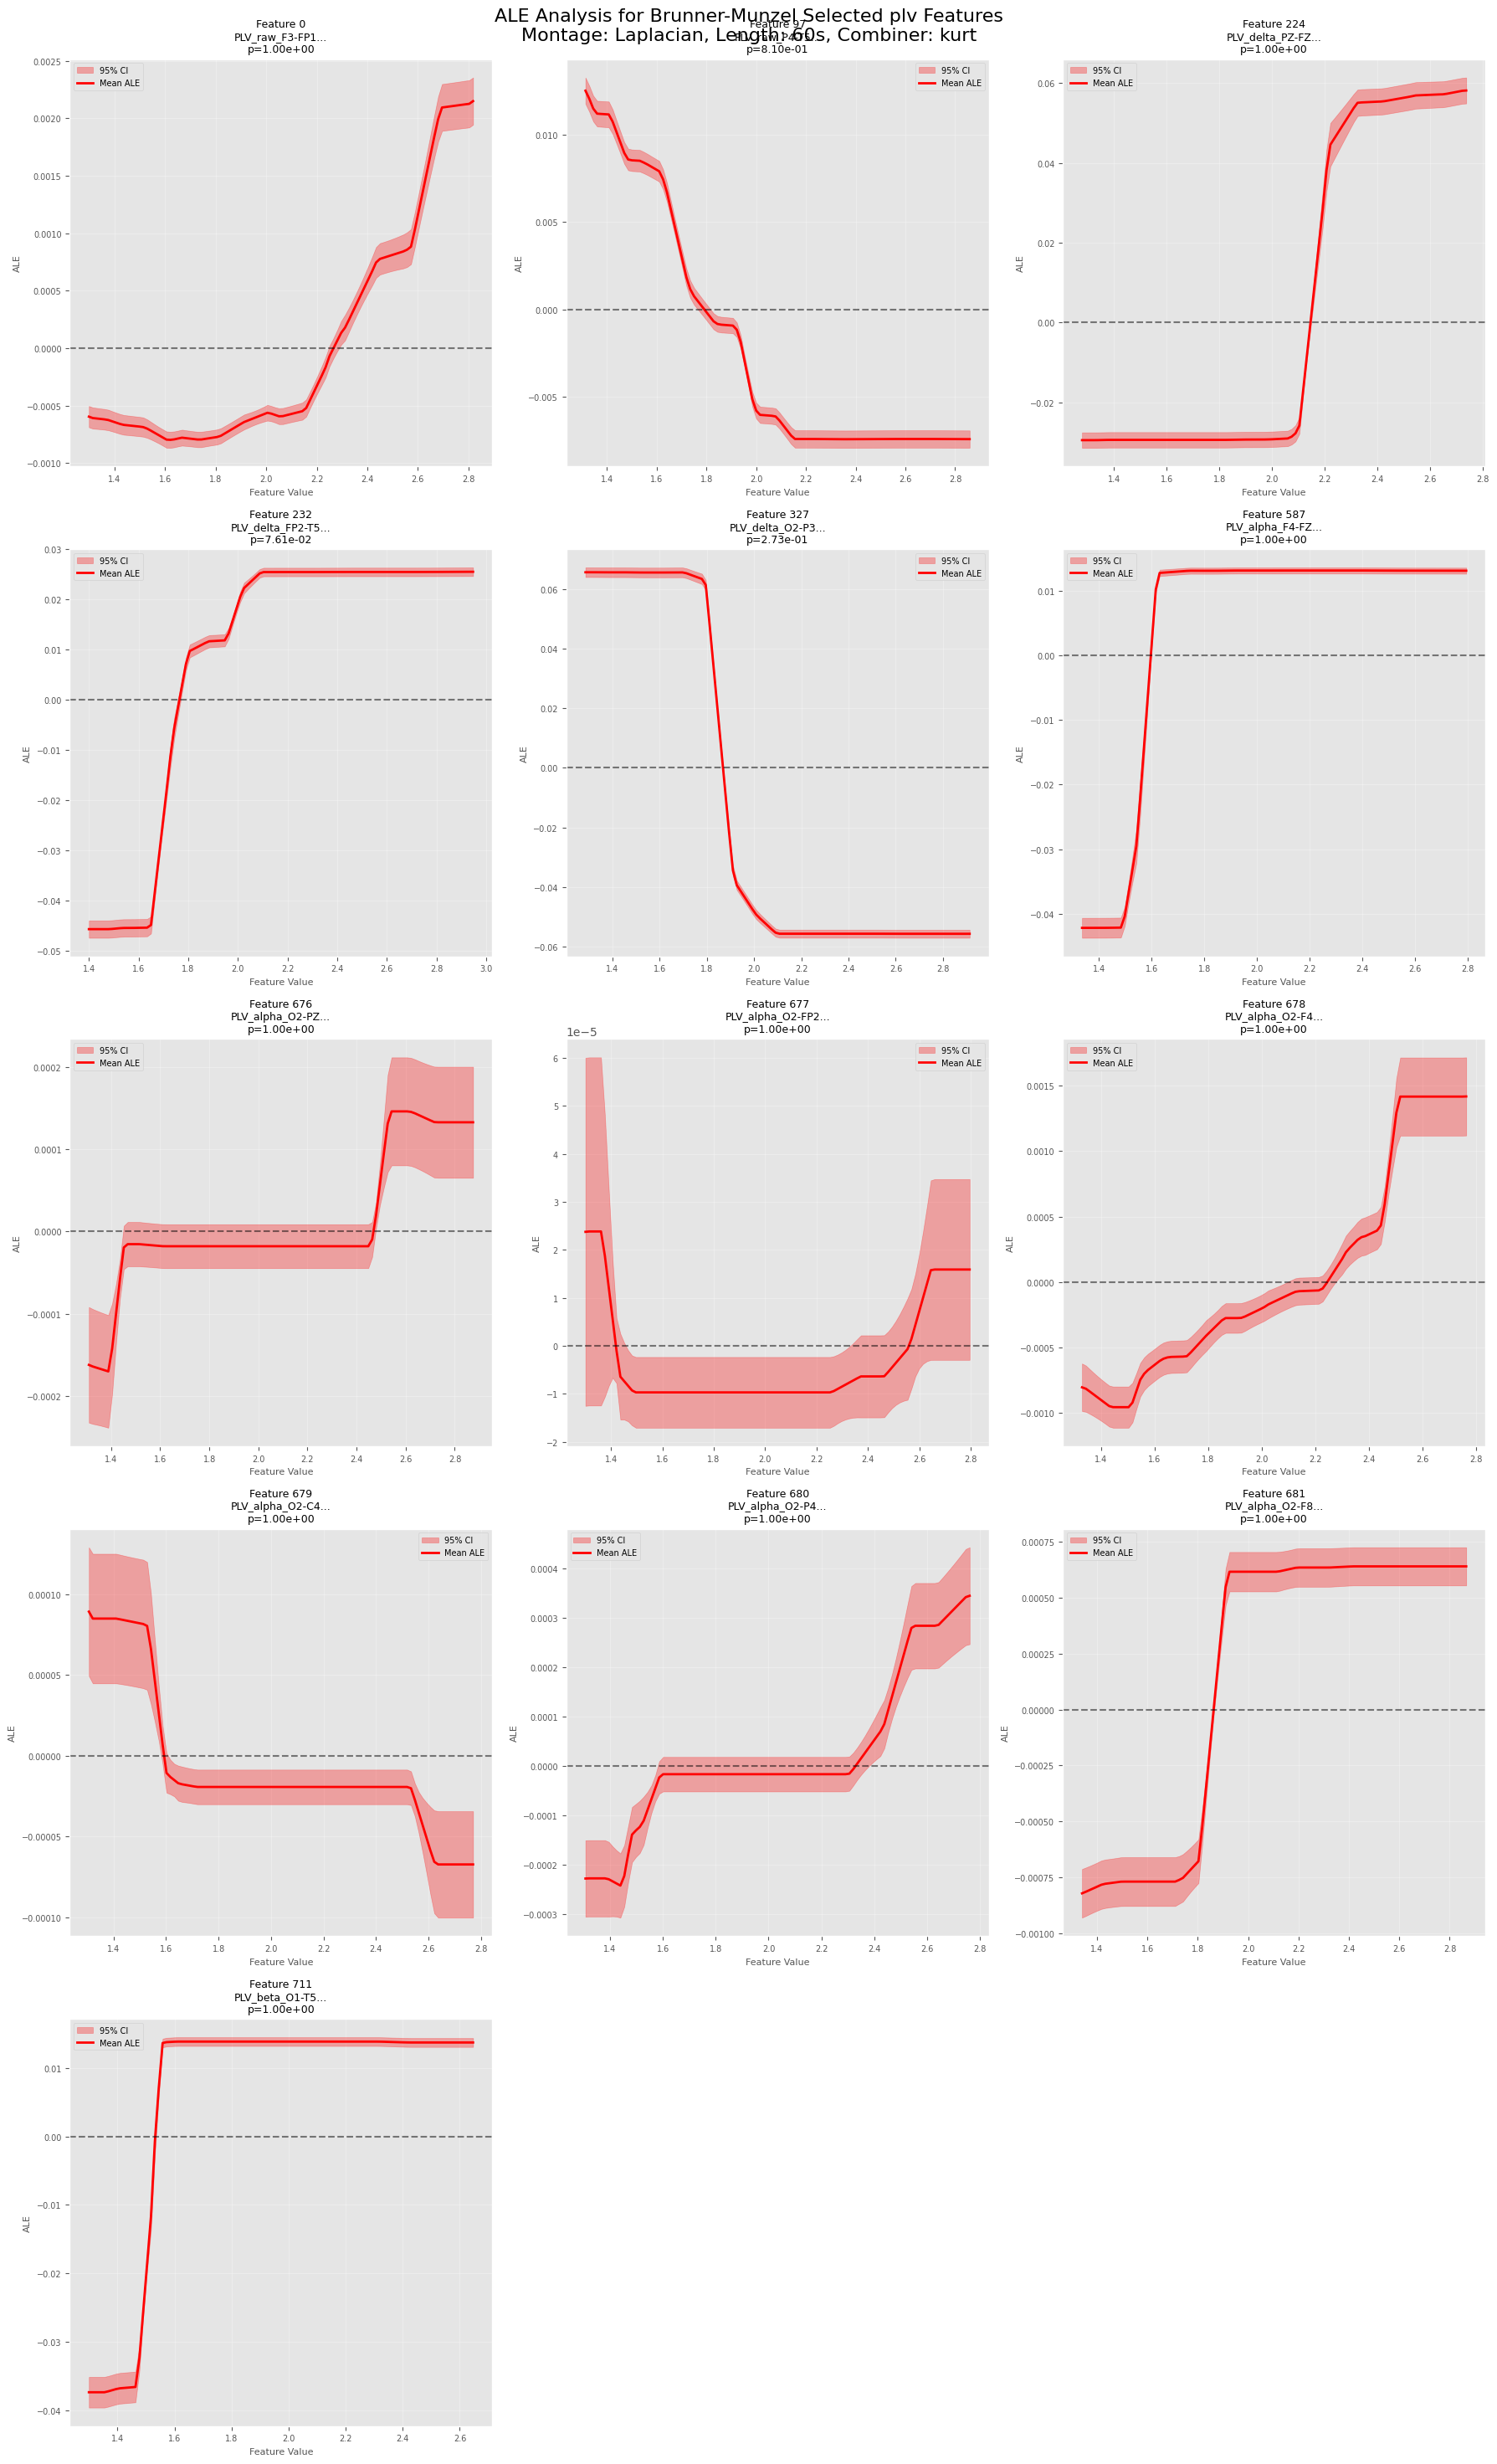

<Figure size 640x480 with 0 Axes>

In [22]:
# Plot ALE results for Brunner-Munzel selected features
print("\n=== PLOTTING ALE RESULTS FOR BRUNNER-MUNZEL SELECTED FEATURES ===")

if len(bm_ale_results) > 0:
    n_cols = 3
    n_rows = (len(bm_ale_results) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, (feat_idx, results) in enumerate(bm_ale_results.items()):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        common_grid = results['common_grid']
        mean_ale = results['mean_ale']
        ci_lower = results['ci_lower']
        ci_upper = results['ci_upper']
        p_val = results['corrected_p_value']
        
        # Plot confidence interval
        valid_mask = ~np.isnan(mean_ale)
        if np.any(valid_mask):
            ax.fill_between(common_grid[valid_mask], ci_lower[valid_mask], ci_upper[valid_mask], 
                           alpha=0.3, color='red', label='95% CI')
            ax.plot(common_grid[valid_mask], mean_ale[valid_mask], 'r-', linewidth=2, label='Mean ALE')
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Feature name and p-value
        if feat_idx < len(feature_names):
            title = f'Feature {feat_idx}\n{feature_names[feat_idx][:40]}...\np={p_val:.2e}'
        else:
            title = f'Feature {feat_idx}\np={p_val:.2e}'
        
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Feature Value', fontsize=8)
        ax.set_ylabel('ALE', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.tick_params(axis='both', which='major', labelsize=7)
    
    # Hide empty subplots
    for i in range(len(bm_ale_results), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].set_visible(False)
    
    plt.suptitle(f'ALE Analysis for Brunner-Munzel Selected {feature_name} Features\n'
                 f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}', 
                 fontsize=16)
    #add space for suptitle
    plt.subplots_adjust(top=0.5)
    plt.tight_layout()
    plt.show()
    
    # Save the plot
    plt.savefig(f'ale_{feature_name}_brunner_munzel_emc.pdf', dpi=300, bbox_inches='tight')

else:
    print("No successful ALE results to plot for Brunner-Munzel selected features")


=== DETAILED PLOTS FOR SPECIFIC AND MOST SIGNIFICANT FEATURES ===
Top 5 most significant features by Brunner-Munzel test:
  1. Feature 232: PLV_delta_FP2-T5 (p=7.61e-02)
  2. Feature 327: PLV_delta_O2-P3 (p=2.73e-01)
  3. Feature 97: PLV_raw_P4-T5 (p=8.10e-01)
  4. Feature 0: PLV_raw_F3-FP1 (p=1.00e+00)
  5. Feature 224: PLV_delta_PZ-FZ (p=1.00e+00)


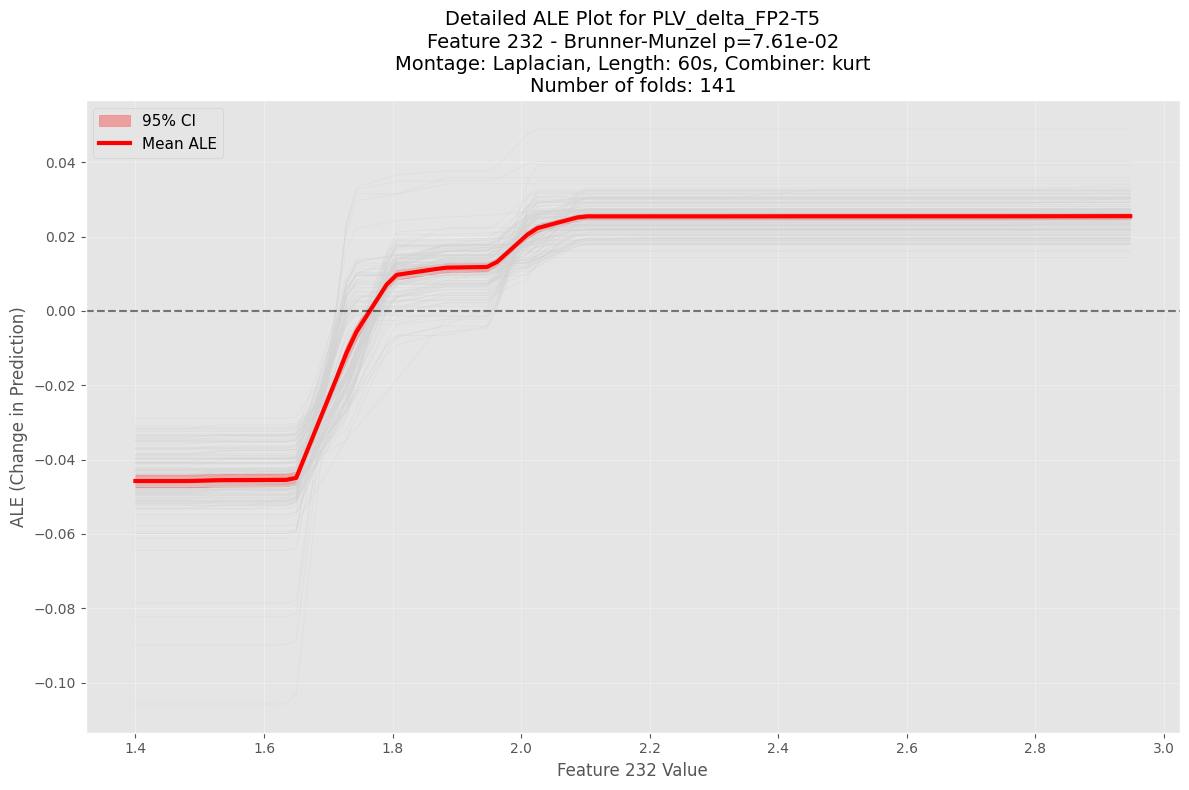

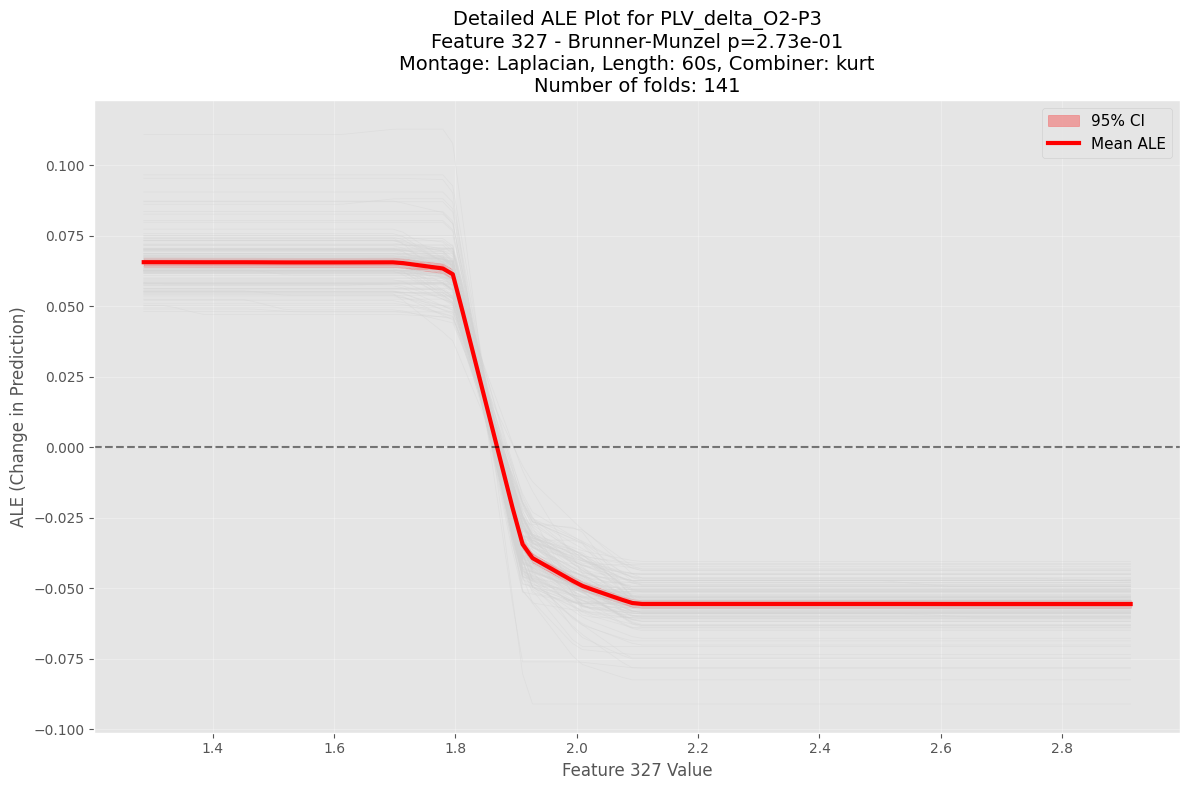

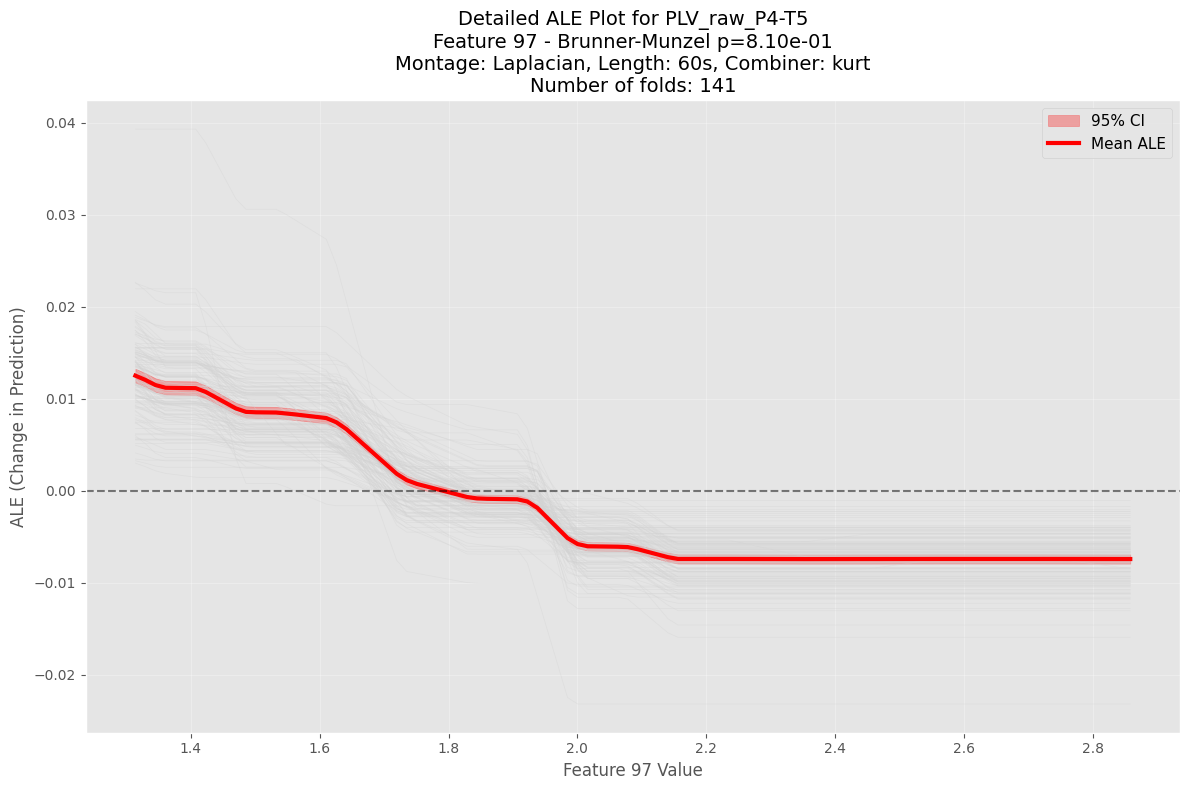

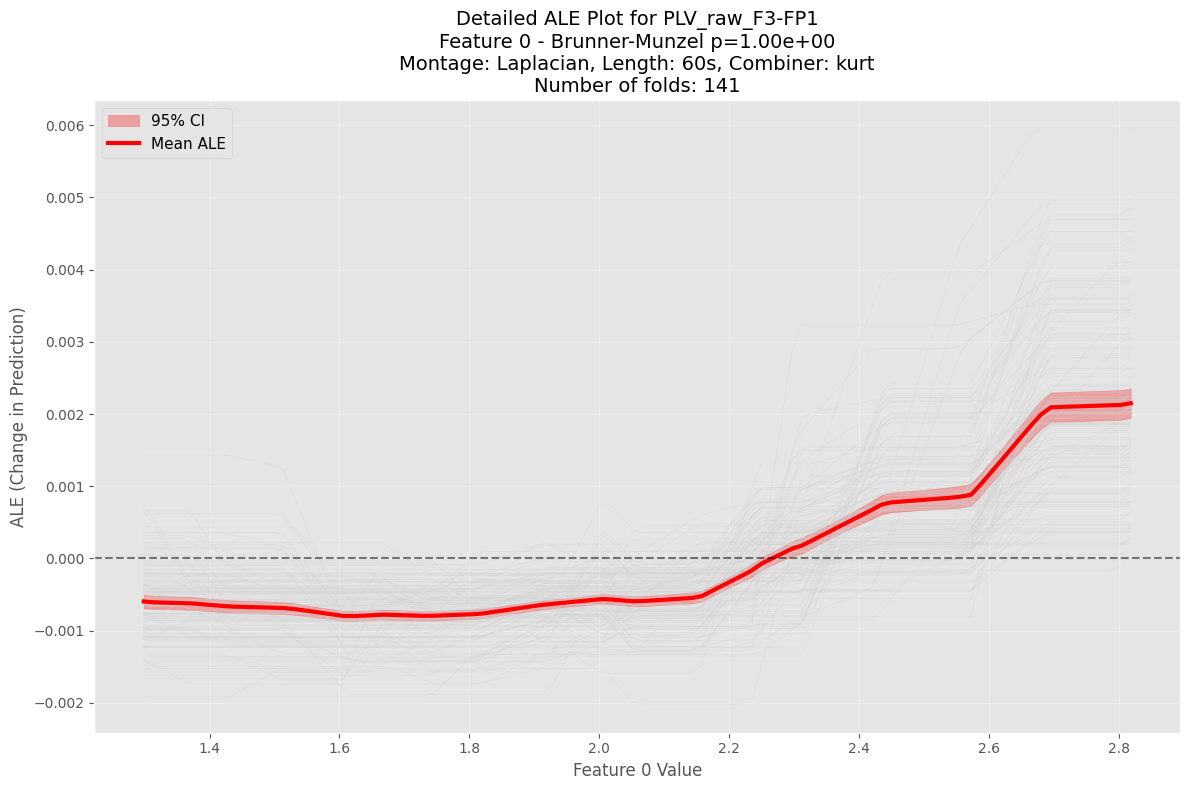

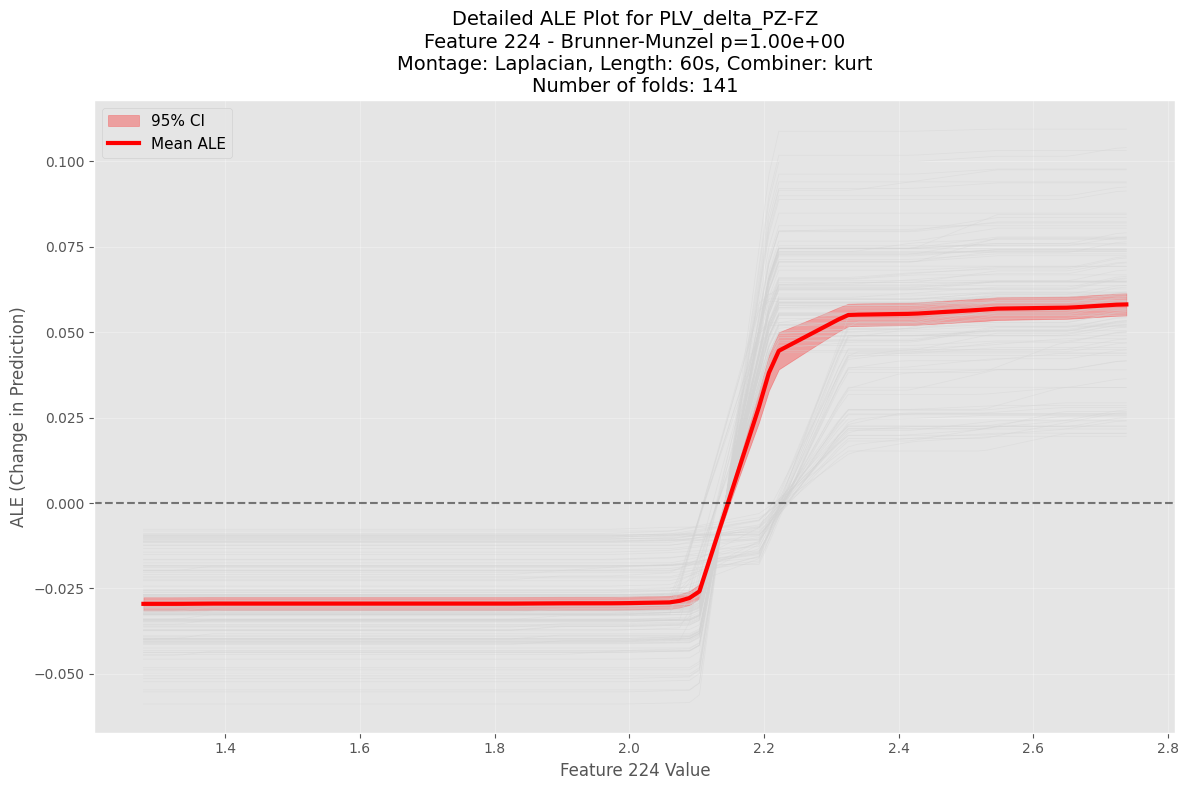


Detailed plots for specifically requested features: [327, 711, 232, 224, 587]


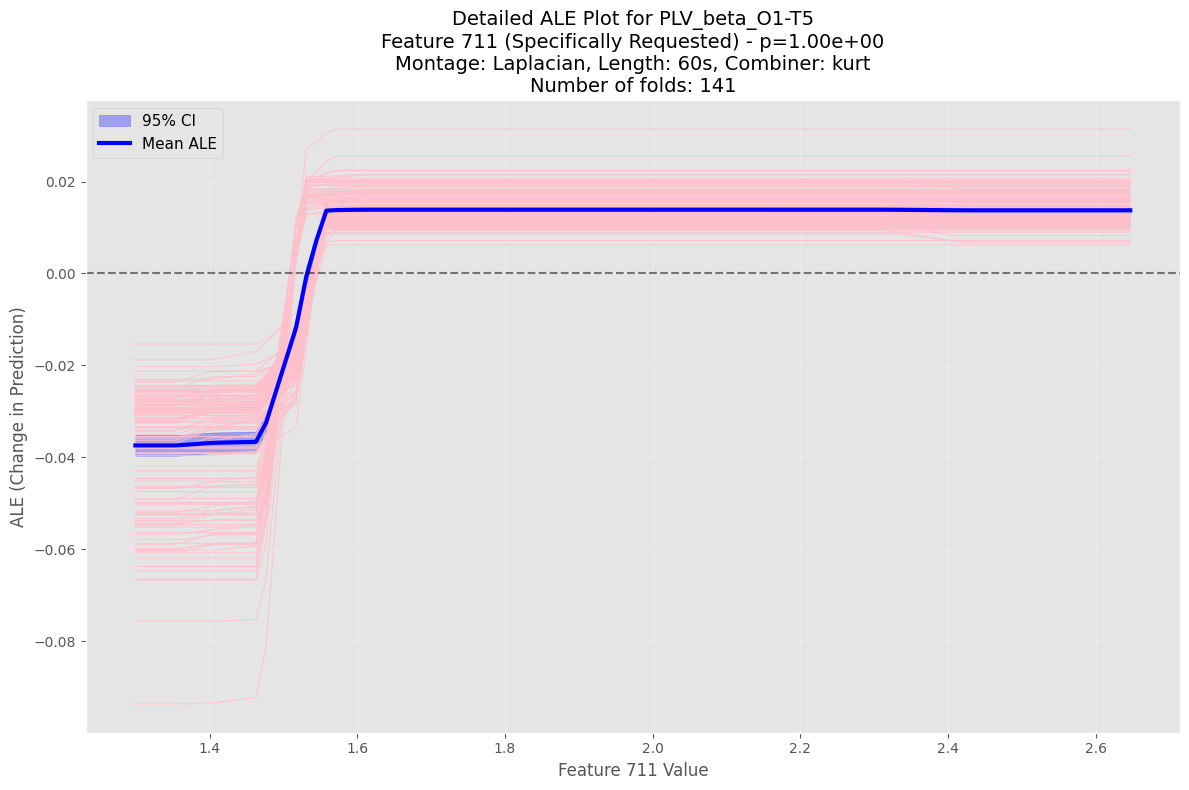

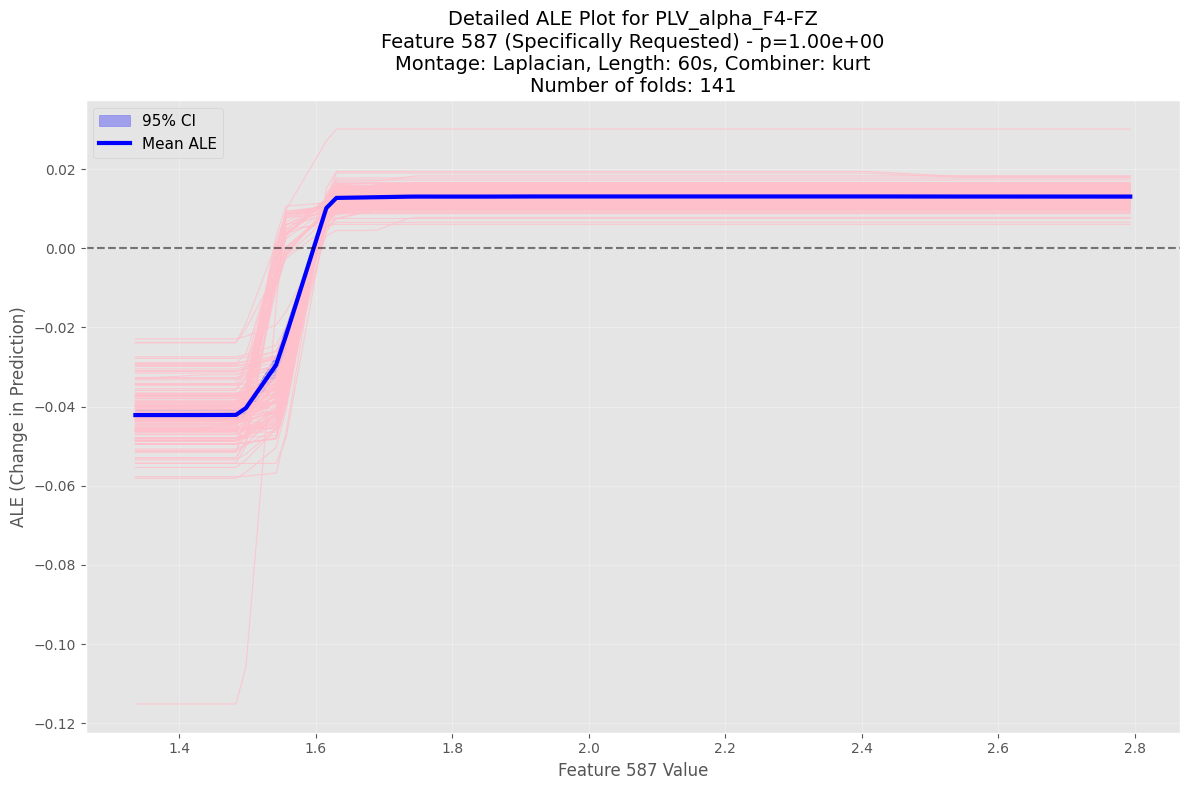

In [34]:
# Create detailed individual plots for specific features and most significant features
print("\n=== DETAILED PLOTS FOR SPECIFIC AND MOST SIGNIFICANT FEATURES ===")

if len(bm_ale_results) > 0:
    # Sort features by corrected p-value (most significant first)
    sorted_bm_features = sorted(bm_ale_results.items(), 
                               key=lambda x: x[1]['corrected_p_value'])
    
    # Take top 5 most significant features
    top_5_significant = sorted_bm_features[:5]
    
    print("Top 5 most significant features by Brunner-Munzel test:")
    for i, (feat_idx, results) in enumerate(top_5_significant):
        p_val = results['corrected_p_value']
        if feat_idx < len(feature_names):
            feat_name = feature_names[feat_idx]
        else:
            feat_name = f"Feature_{feat_idx}"
        print(f"  {i+1}. Feature {feat_idx}: {feat_name} (p={p_val:.2e})")
    
    # Create detailed plots for top significant features
    for feat_idx, results in top_5_significant:
        # Collect individual fold ALE curves for plotting
        individual_folds = []
        for ale_values, bin_centers, bin_counts, n_train in results['fold_results']:
            ale_centered = ale_values - np.average(ale_values, weights=bin_counts)
            interpolated = interpolate_ale_to_common_grid(ale_centered, bin_centers, results['common_grid'])
            individual_folds.append(interpolated)
        
        # Create detailed plot
        plt.figure(figsize=(12, 8))
        
        # Plot individual fold curves (faint)
        for fold_ale in individual_folds:
            plt.plot(results['common_grid'], fold_ale, 'lightgray', alpha=0.4, linewidth=0.5)
        
        # Plot confidence interval and mean
        valid_mask = ~np.isnan(results['mean_ale'])
        if np.any(valid_mask):
            plt.fill_between(results['common_grid'][valid_mask], 
                           results['ci_lower'][valid_mask], 
                           results['ci_upper'][valid_mask], 
                           alpha=0.3, color='red', label='95% CI')
            plt.plot(results['common_grid'][valid_mask], 
                    results['mean_ale'][valid_mask], 
                    'r-', linewidth=3, label='Mean ALE')
            plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Feature information
        if feat_idx < len(feature_names):
            feat_name = feature_names[feat_idx]
            plt.title(f'Detailed ALE Plot for {feat_name}\n'
                     f'Feature {feat_idx} - Brunner-Munzel p={results["corrected_p_value"]:.2e}\n'
                     f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}\n'
                     f'Number of folds: {results["n_folds"]}', fontsize=14)
        else:
            plt.title(f'Detailed ALE Plot for Feature {feat_idx}\n'
                     f'Brunner-Munzel p={results["corrected_p_value"]:.2e}\n'
                     f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}\n'
                     f'Number of folds: {results["n_folds"]}', fontsize=14)
        
        plt.xlabel(f'Feature {feat_idx} Value', fontsize=12)
        plt.ylabel('ALE (Change in Prediction)', fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Save individual plot
        plt.savefig(f'ale_{feature_name}_feature_{feat_idx}_brunner_munzel_emc.pdf', 
                   dpi=300, bbox_inches='tight')
        plt.close()
    
    # Also create plots for specific features if they were successfully analyzed
    specific_features_analyzed = [f for f in specific_features if f in bm_ale_results]
    if specific_features_analyzed:
        print(f"\nDetailed plots for specifically requested features: {specific_features_analyzed}")
        
        for feat_idx in specific_features_analyzed:
            if feat_idx in [f[0] for f in top_5_significant]:
                continue  # Already plotted above
                
            results = bm_ale_results[feat_idx]
            
            # Collect individual fold ALE curves
            individual_folds = []
            for ale_values, bin_centers, bin_counts, n_train in results['fold_results']:
                ale_centered = ale_values - np.average(ale_values, weights=bin_counts)
                interpolated = interpolate_ale_to_common_grid(ale_centered, bin_centers, results['common_grid'])
                individual_folds.append(interpolated)
            
            # Create detailed plot
            plt.figure(figsize=(12, 8))
            
            # Plot individual fold curves (faint)
            for fold_ale in individual_folds:
                plt.plot(results['common_grid'], fold_ale, 'pink', alpha=0.8, linewidth=0.8)
            
            # Plot confidence interval and mean
            valid_mask = ~np.isnan(results['mean_ale'])
            if np.any(valid_mask):
                plt.fill_between(results['common_grid'][valid_mask], 
                               results['ci_lower'][valid_mask], 
                               results['ci_upper'][valid_mask], 
                               alpha=0.3, color='blue', label='95% CI')
                plt.plot(results['common_grid'][valid_mask], 
                        results['mean_ale'][valid_mask], 
                        'b-', linewidth=3, label='Mean ALE')
                plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            
            # Feature information
            if feat_idx < len(feature_names):
                feat_name = feature_names[feat_idx]
                plt.title(f'Detailed ALE Plot for {feat_name}\n'
                         f'Feature {feat_idx} (Specifically Requested) - p={results["corrected_p_value"]:.2e}\n'
                         f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}\n'
                         f'Number of folds: {results["n_folds"]}', fontsize=14)
            else:
                plt.title(f'Detailed ALE Plot for Feature {feat_idx}\n'
                         f'(Specifically Requested) - p={results["corrected_p_value"]:.2e}\n'
                         f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}\n'
                         f'Number of folds: {results["n_folds"]}', fontsize=14)
            
            plt.xlabel(f'Feature {feat_idx} Value', fontsize=12)
            plt.ylabel('ALE (Change in Prediction)', fontsize=12)
            plt.legend(fontsize=11)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Save individual plot
            plt.savefig(f'ale_{feature_name}_feature_{feat_idx}_specific_emc.pdf', 
                       dpi=300, bbox_inches='tight')
            plt.close()

else:
    print("No ALE results available for detailed plotting")

In [19]:
# Comprehensive summary for Brunner-Munzel analysis
print("\n" + "="*60)
print("=== COMPREHENSIVE SUMMARY: BRUNNER-MUNZEL ALE ANALYSIS ===")
print("="*60)

print(f"\nFeature type: {feature_name}")
print(f"Montage: {montage}, Segment length: {segment_length}s, Combiner: {combiner}")
print(f"Total features in dataset: {data.shape[1]}")
print(f"Total subjects (LOSO folds): {len(unique_subjects)}")

# Brunner-Munzel test results
n_significant_features = np.sum(bm_corrected_p_values < 0.05)
n_valid_tests = np.sum(bm_p_values < 1.0)
print(f"\nBrunner-Munzel Test Results:")
print(f"  Features tested: {n_valid_tests}")
print(f"  Significant features (corrected p < 0.05): {n_significant_features}")
print(f"  Features selected for ALE: {len(features_to_analyze)}")
print(f"  Successful ALE computations: {len(bm_ale_results)}")

if len(bm_ale_results) > 0:
    avg_folds_bm = np.mean([results['n_folds'] for results in bm_ale_results.values()])
    print(f"  Average successful folds per feature: {avg_folds_bm:.1f}")
    
    # Report most significant features
    print(f"\nMost significant features by Brunner-Munzel test:")
    sorted_significant = sorted([(feat_idx, results['corrected_p_value']) 
                               for feat_idx, results in bm_ale_results.items()], 
                              key=lambda x: x[1])
    
    for i, (feat_idx, p_val) in enumerate(sorted_significant[:10]):
        if feat_idx < len(feature_names):
            feat_name = feature_names[feat_idx][:80] + "..." if len(feature_names[feat_idx]) > 80 else feature_names[feat_idx]
        else:
            feat_name = f"Feature_{feat_idx}"
        print(f"  {i+1:2d}. Feature {feat_idx:3d}: {feat_name}")
        print(f"      Corrected p-value: {p_val:.2e}")
    
    # Report features with strongest ALE effects among BM-selected features
    print(f"\nBrunner-Munzel selected features with strongest ALE effects:")
    bm_max_ale_effects = {}
    for feat_idx, results in bm_ale_results.items():
        mean_ale = results['mean_ale']
        valid_mask = ~np.isnan(mean_ale)
        if np.any(valid_mask):
            bm_max_ale_effects[feat_idx] = np.max(np.abs(mean_ale[valid_mask]))
        else:
            bm_max_ale_effects[feat_idx] = 0
    
    sorted_bm_effects = sorted(bm_max_ale_effects.items(), key=lambda x: x[1], reverse=True)
    for i, (feat_idx, max_effect) in enumerate(sorted_bm_effects[:10]):
        p_val = bm_ale_results[feat_idx]['corrected_p_value']
        if feat_idx < len(feature_names):
            feat_name = feature_names[feat_idx][:60] + "..." if len(feature_names[feat_idx]) > 60 else feature_names[feat_idx]
        else:
            feat_name = f"Feature_{feat_idx}"
        print(f"  {i+1:2d}. Feature {feat_idx:3d}: {feat_name}")
        print(f"      Max |ALE|: {max_effect:.4f}, p-value: {p_val:.2e}")
    
    # Status of specifically requested features
    print(f"\nStatus of specifically requested features {specific_features}:")
    for feat_idx in specific_features:
        if feat_idx < data.shape[1]:
            if feat_idx in bm_ale_results:
                p_val = bm_ale_results[feat_idx]['corrected_p_value']
                max_ale = bm_max_ale_effects.get(feat_idx, 0)
                n_folds = bm_ale_results[feat_idx]['n_folds']
                status = "✓ Successfully analyzed"
                print(f"  Feature {feat_idx}: {status}")
                print(f"    p-value: {p_val:.2e}, Max |ALE|: {max_ale:.4f}, Folds: {n_folds}")
            else:
                p_val = bm_p_values[feat_idx] if feat_idx < len(bm_p_values) else 1.0
                corrected_p_val = bm_corrected_p_values[feat_idx] if feat_idx < len(bm_corrected_p_values) else 1.0
                status = "✗ ALE analysis failed"
                print(f"  Feature {feat_idx}: {status}")
                print(f"    p-value: {p_val:.2e}, Corrected p-value: {corrected_p_val:.2e}")
        else:
            print(f"  Feature {feat_idx}: ✗ Index out of range (max: {data.shape[1]-1})")

print(f"\nComparison with variance-based selection:")
print(f"  Variance-based features analyzed: {len(ale_results)}")
print(f"  Brunner-Munzel features analyzed: {len(bm_ale_results)}")

# Find overlap between methods
if len(ale_results) > 0 and len(bm_ale_results) > 0:
    variance_features = set(ale_results.keys())
    bm_features = set(bm_ale_results.keys())
    overlap = variance_features.intersection(bm_features)
    print(f"  Overlapping features: {len(overlap)} - {sorted(list(overlap))}")

print(f"\nBrunner-Munzel ALE analysis completed!")
print("="*60)


=== COMPREHENSIVE SUMMARY: BRUNNER-MUNZEL ALE ANALYSIS ===

Feature type: plv
Montage: Laplacian, Segment length: 60s, Combiner: kurt
Total features in dataset: 1026
Total subjects (LOSO folds): 141

Brunner-Munzel Test Results:
  Features tested: 1026
  Significant features (corrected p < 0.05): 0
  Features selected for ALE: 13
  Successful ALE computations: 13
  Average successful folds per feature: 141.0

Most significant features by Brunner-Munzel test:
   1. Feature 232: PLV_delta_FP2-T5
      Corrected p-value: 7.61e-02
   2. Feature 327: PLV_delta_O2-P3
      Corrected p-value: 2.73e-01
   3. Feature  97: PLV_raw_P4-T5
      Corrected p-value: 8.10e-01
   4. Feature   0: PLV_raw_F3-FP1
      Corrected p-value: 1.00e+00
   5. Feature 224: PLV_delta_PZ-FZ
      Corrected p-value: 1.00e+00
   6. Feature 587: PLV_alpha_F4-FZ
      Corrected p-value: 1.00e+00
   7. Feature 676: PLV_alpha_O2-PZ
      Corrected p-value: 1.00e+00
   8. Feature 677: PLV_alpha_O2-FP2
      Corrected p-v